In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# FILTER TO BOILER → AC OPPORTUNITY CUSTOMERS
print("\n🎯 FILTERING TO BOILER → AC OPPORTUNITY")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

# Get customers with boiler
has_boiler = df_quotes.groupby('numero_compte')['famille_equipement_produit'].apply(
    lambda x: 'Chaudière' in x.values
)

# Get customers with AC
has_ac = df_quotes.groupby('numero_compte')['famille_equipement_produit'].apply(
    lambda x: 'Climatisation' in x.values
)

# Boiler → AC opportunity: has boiler, no AC
boiler_to_ac_ids = has_boiler[has_boiler & (~has_ac)].index.tolist()

# Filter data
df_quotes_boiler_ac = df_quotes[df_quotes['numero_compte'].isin(boiler_to_ac_ids)].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"Boiler → AC opportunity: {len(boiler_to_ac_ids):,} customers")
print(f"Quotes: {len(df_quotes_boiler_ac):,}")

# Save to file
df_quotes_boiler_ac.to_csv('cleaned_quote_data_boiler_ac.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_boiler_ac.csv")


🎯 FILTERING TO BOILER → AC OPPORTUNITY
Original customers: 25,716
Boiler → AC opportunity: 7,981 customers
Quotes: 11,181

✅ Saved to cleaned_quote_data_boiler_ac.csv


In [3]:
df_quotes = pd.read_csv('cleaned_quote_data_boiler_ac.csv')


📊 Original quote data: 11,181 quotes from 7,981 customers

🏗️  BUILDING FEATURES FOR SUBPOPULATION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 7,981, Quotes: 11,058
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 7,981 customers | 42.0% converters
⏱️  Execution time: 3.3 seconds
⚠️  3.3s (target was 3s)
CREATING SEQUENCE FEATURES (mode: first_conversion)
  Total quotes: 11,181
  Total customers: 7,981
  Using product column: regroup_famille_equipement_produit_principal
  Window days: 30
  Filtering post-first-purchase data...
    Customers after filter: 7,981
    Quotes after filter: 11,068
⚡ Processing 7,981 customers with sequence features...
  Processed 5,000/7,981 customers

  Adding categorical features...

✅ SEQUENCE FEATURES CREATED
  Total customers: 7,981
  Converters: 3,355 (42.0%)
  Features created: 21
  Product column used: regro

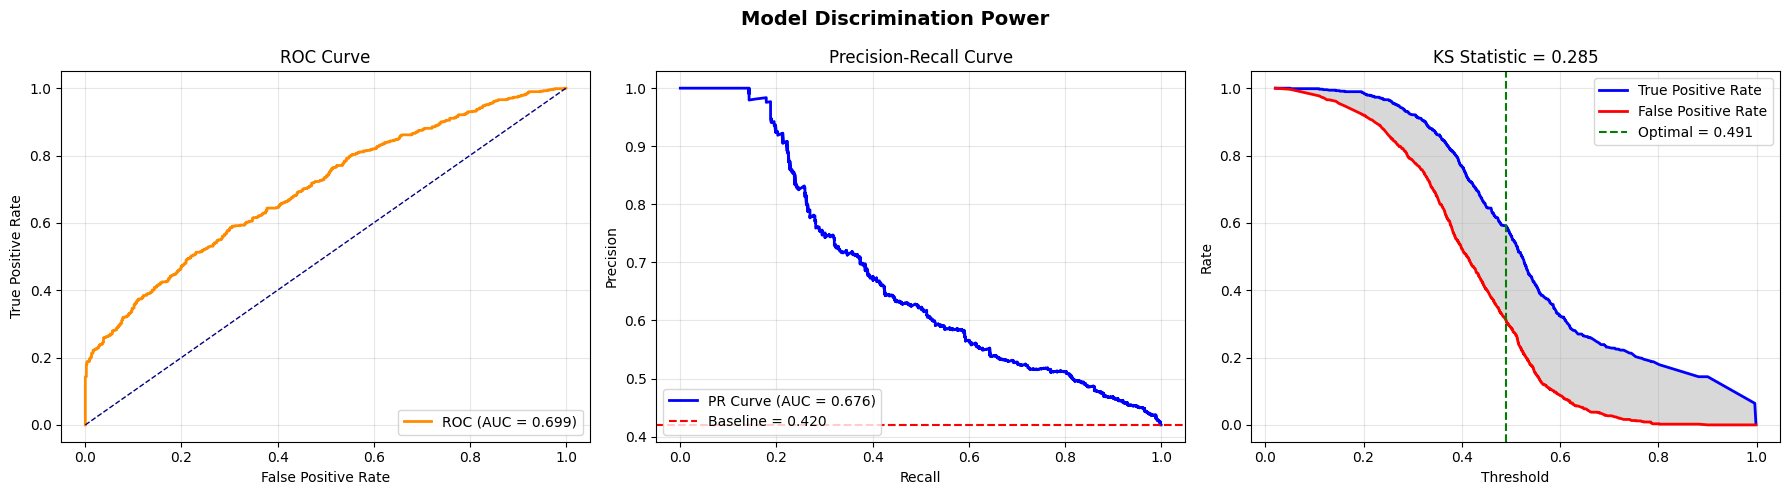

• ROC-AUC: 0.6994
• PR-AUC: 0.6760
• KS Statistic: 0.285 (WEAK discrimination)
• Optimal Threshold: 0.491

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.912
Decile 10 mean prob: 0.180


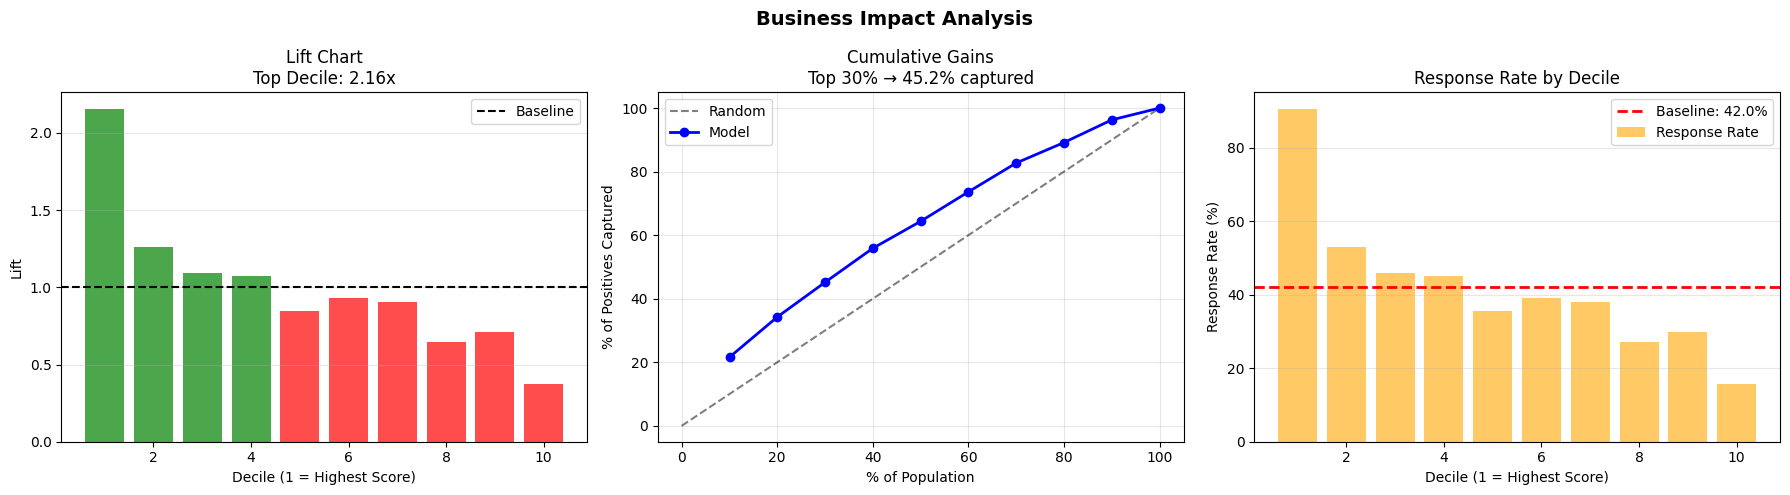

• Top Decile Lift: 0.37x
• Top 30% captures: 45.2% of positives
• Baseline response rate: 42.0%
• Top decile response: 90.6%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


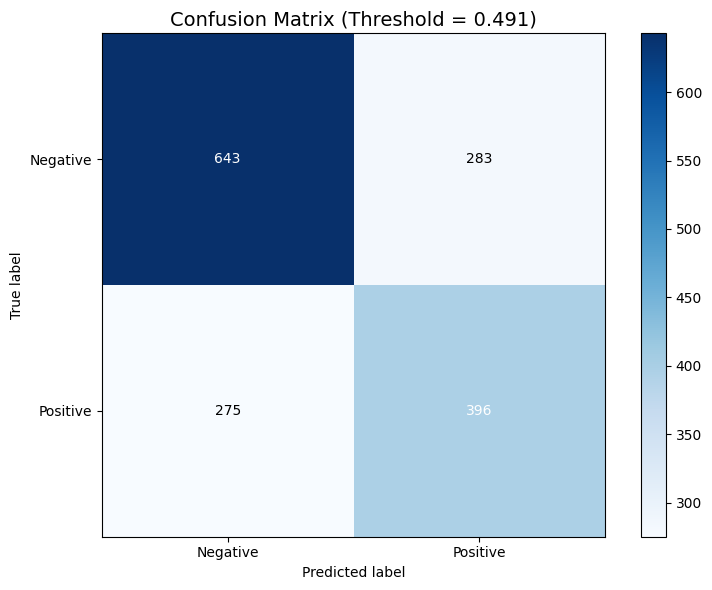

At threshold 0.491:
• Accuracy: 0.651
• Precision: 0.583
• Recall: 0.590
• F1-Score: 0.587
• True Positives: 396
• False Positives: 283
• True Negatives: 643
• False Negatives: 275

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.285 (WEAK discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.37x better than random
   Coverage: Top 30% → 45.2% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.6994 (Excellent if >0.8)
   PR-AUC: 0.6760 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.491
   Precision at threshold: 0.583
   Recall at threshold: 0.590

🔍 FEATURE IMPORTANCE - SUBPOPULATION MODEL

Top 20 Features:
                         feature  importance
177      quote_consistency_score    0.074531
226        browser_pattern_score    0.061138
154           engagement_density    0.029011
28          prefers_budget_brand    0.016112
166             is_quick_decider    0.015645
153              engagement_days    0.015432
38           model_variety_score    0.0

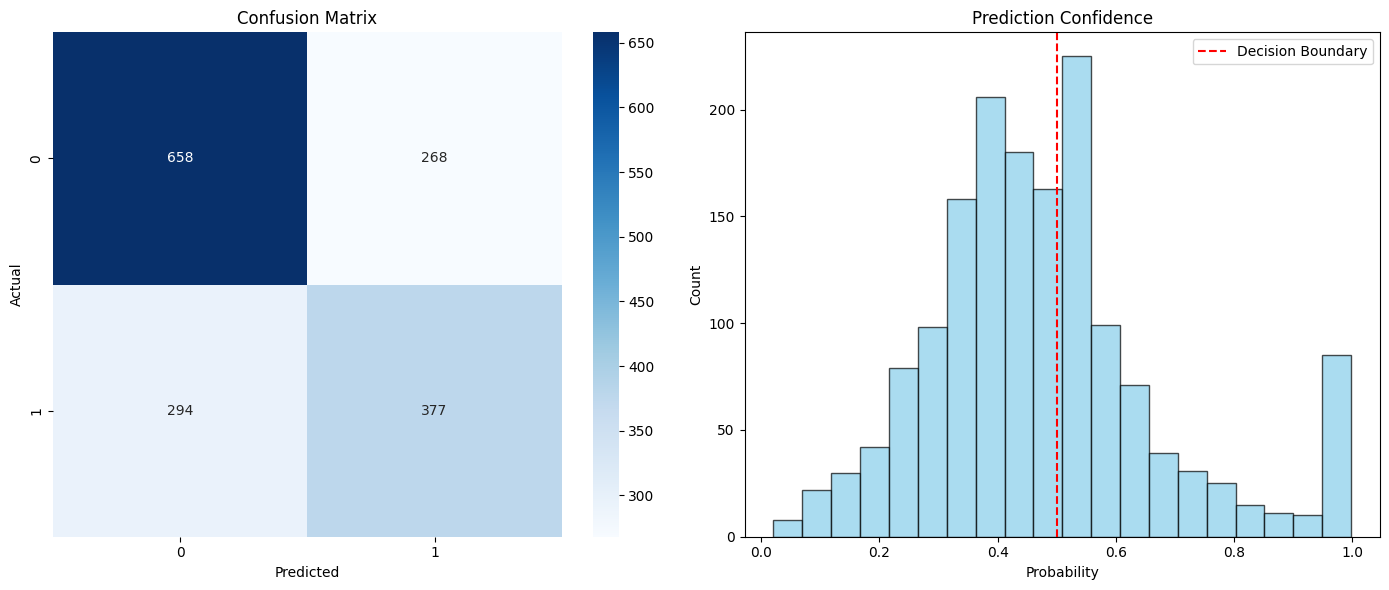

In [4]:
#with redirect_stdout(open('/dev/null', 'w')):
result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])